# `racket_trajectory` API

A guided exploration of `racket_trajectory.py` (and the `racket_params.py`
module it depends on) from `research/Optimal_strategy_for_racket_sports/`:
- **Core abstraction**: closed-form projectile physics for a point-mass ball,
  plus Monte Carlo sampling of shot execution error
- **Use case**: given a striker position, a target, and a sport, find which
  launch angles/speeds are physically feasible, then see where noisy shots
  actually land
- **Learning path**: sport parameters -> vertical-plane physics -> feasible
  launch set -> error propagation and landing simulation

This notebook only covers the modules implemented so far (`PR1`, `PR2` of
`plan.racket_strategy.md`). Scoring, the placement game, and interactive
widgets are added by later PRs.

## Imports and Setup

In [1]:
%load_ext autoreload
%autoreload 2

import logging

import numpy as np
import pandas as pd

In [2]:
import helpers.hdbg as hdbg
import helpers.hintrospection as hintros
import helpers.hnotebook as hnotebook
from research.Optimal_strategy_for_racket_sports import racket_params
from research.Optimal_strategy_for_racket_sports import racket_trajectory
from research.Optimal_strategy_for_racket_sports.notebooks import (
    racket_trajectory_utils as utils,
)

hdbg.init_logger(verbosity=logging.INFO)
_LOG = logging.getLogger(__name__)
hnotebook.config_notebook()

try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore

INFO  > /usr/local/lib/python3.12/site-packages/ipykernel_launcher.py -f /root/.local/share/jupyter/runtime/kernel-652f2217-81d7-458e-91b4-a12d2e8c0398.json


## Library Overview

- **What problem it solves**: turns a paper's closed-form projectile
  equations into tested, reusable functions and a shared parameter model
  for tennis and pickleball
- **Key abstraction**: a shot is a `(theta, v0)` launch from a contact
  height; feasibility means it clears the net and lands at the target
  within the sport's max ball speed
- **Mental model**:

| Object | Description | Comments |
|--------|-------------|----------|
| `SportParams` | Sport-specific constants | `TENNIS`, `PICKLEBALL` presets |
| `CourtGeometry` | Court and net dimensions | Held by `SportParams.court` |
| `get_flight_time()` | Time to reach `z=0` | Solves a quadratic in `t` |
| `get_height_at(x)` | Ball height at distance `x` | Closed-form, no drag |
| `solve_launch_speed()` | `v0` that lands at `d_target` | Inverts the range equation |
| `FeasibleLaunches` | Survivors of one angle sweep | Shape `(L,)`, one target |
| `ShotErrorModel` / `ShotErrors` | Execution noise model / draws | 3 std devs / 3 samples |
| `Landings` | Simulated landing points | Shape `(L, K)` |

- **Key classes/functions**:
  - `racket_params.SportParams`, `racket_params.CourtGeometry`: static
    inputs, covered in `racket_params.py`
  - `racket_trajectory.get_flight_time()`, `get_height_at()`,
    `solve_launch_speed()`: vertical-plane physics
  - `racket_trajectory.get_feasible_launches()`: sweeps a grid of launch
    angles and keeps the ones that clear the net within the speed limit
  - `racket_trajectory.sample_shot_errors()`,
    `racket_trajectory.simulate_landings()`: propagate execution noise into
    a `(L, K)` grid of landing points

# Part 1: Sport Parameters (`racket_params`)

## Cell 1.1: `SportParams` and `CourtGeometry`: Table I as a table

- `racket_trajectory` never builds its own court numbers: every function
  below takes a `sport: SportParams` argument and reads `sport.court` for
  net height and `sport.max_ball_speed_mps` for the speed limit

In [3]:
# Link to the class definition on GitHub, and list its public surface.
hintros.print_obj_info(racket_params.SportParams)
# Outcome: `SportParams` exposes no public methods beyond the dataclass
# defaults; its interface is its 3 fields (name, court, max_ball_speed_mps).

**SportParams**

https://github.com/gpsaggese/gpsaggese.github.io/blob/UmdTask590_Implement_solution_for_optimal_strategy_for_racket_sports_1/research/Optimal_strategy_for_racket_sports/racket_params.py#L111


In [4]:
# Build a Table I comparison DataFrame directly from the two presets.
sports_df = pd.DataFrame(
    {
        "Tennis": {
            "length_m": racket_params.TENNIS.court.length_m,
            "width_m": racket_params.TENNIS.court.width_m,
            "net_height_center_m": (
                racket_params.TENNIS.court.net_height_center_m
            ),
            "max_ball_speed_mps": racket_params.TENNIS.max_ball_speed_mps,
        },
        "Pickleball": {
            "length_m": racket_params.PICKLEBALL.court.length_m,
            "width_m": racket_params.PICKLEBALL.court.width_m,
            "net_height_center_m": (
                racket_params.PICKLEBALL.court.net_height_center_m
            ),
            "max_ball_speed_mps": racket_params.PICKLEBALL.max_ball_speed_mps,
        },
    }
)
display(sports_df)
# Outcome: tennis has the longer, wider court and the higher net, but
# pickleball's max ball speed is far lower, both close to Table I.

,Tennis,Pickleball
length_m,23.770,13.410
width_m,8.230,6.100
net_height_center_m,0.914,0.867
max_ball_speed_mps,73.140,24.590


## Cell 1.2: `get_net_height()`: the net height profile

- Linear interpolation from the center height to the post height at the
  singles sideline; `x=0` is the center line

In [5]:
hintros.print_obj_info(racket_params.get_net_height)

- `get_net_height(court: research.Optimal_strategy_for_racket_sports.racket_params.CourtGeometry, x: numpy.ndarray) -> numpy.ndarray`  
  Net height as a function of lateral position x.

https://github.com/gpsaggese/gpsaggese.github.io/blob/UmdTask590_Implement_solution_for_optimal_strategy_for_racket_sports_1/research/Optimal_strategy_for_racket_sports/racket_params.py#L199


In [6]:
# Evaluate the net height at the center, sideline, and midway between them.
court = racket_params.TENNIS.court
x_positions = np.array([0.0, court.width_m / 4, court.width_m / 2])
net_heights = racket_params.get_net_height(court, x_positions)
print("x_positions (m):", x_positions)
print("net_heights (m):", net_heights)
# Outcome: 0.914 m at the center, rising linearly to 1.07 m at the sideline.

x_positions (m): [0.     2.0575 4.115 ]
net_heights (m): [0.914 0.992 1.07 ]


# Part 2: Vertical-Plane Trajectory Physics

## Cell 2.1: `get_flight_time()`: time to return to `z=0`

In [7]:
hintros.print_obj_info(racket_trajectory.get_flight_time)

- `get_flight_time(v0: numpy.ndarray, theta: numpy.ndarray, h0: float) -> numpy.ndarray`  
  Time of flight until the ball returns to ground level (`z = 0`).

https://github.com/gpsaggese/gpsaggese.github.io/blob/UmdTask590_Implement_solution_for_optimal_strategy_for_racket_sports_1/research/Optimal_strategy_for_racket_sports/racket_trajectory.py#L89


In [8]:
# Textbook case: with h0=0, flight time is the classic 2*v0*sin(theta)/g.
v0 = np.array([20.0])
theta = np.array([np.radians(30.0)])
h0 = 0.0
flight_time = racket_trajectory.get_flight_time(v0, theta, h0)
print("flight_time (s):", flight_time)
# Outcome: 2.04 s, matching `2 * 20 * sin(30deg) / GRAVITY_MPS2` exactly.

flight_time (s): [2.03873598]


## Cell 2.2: `get_height_at()`: height along the flight path

In [9]:
hintros.print_obj_info(racket_trajectory.get_height_at)

- `get_height_at(x: numpy.ndarray, v0: numpy.ndarray, theta: numpy.ndarray, h0: float) -> numpy.ndarray`  
  Ball height at horizontal distance `x` along the flight path.

https://github.com/gpsaggese/gpsaggese.github.io/blob/UmdTask590_Implement_solution_for_optimal_strategy_for_racket_sports_1/research/Optimal_strategy_for_racket_sports/racket_trajectory.py#L110


## Cell 2.3: `solve_launch_speed()`: reproducing the paper's Figure 1

- The paper's Figure 1 example: `theta=8 deg`, `d_target=20 m`, `h0=1 m`
- `test_racket_trajectory.py` checks these exact numbers, so this cell
  should reproduce them

In [10]:
hintros.print_obj_info(racket_trajectory.solve_launch_speed)

- `solve_launch_speed(d_target: numpy.ndarray, theta: numpy.ndarray, h0: float) -> numpy.ndarray`  
  Launch speed that lands the ball exactly at `d_target`.

https://github.com/gpsaggese/gpsaggese.github.io/blob/UmdTask590_Implement_solution_for_optimal_strategy_for_racket_sports_1/research/Optimal_strategy_for_racket_sports/racket_trajectory.py#L134


In [11]:
# Solve for the launch speed that lands exactly at 20 m, at an 8 deg angle.
d_target = np.array([20.0])
theta_fig1 = np.array([np.radians(8.0)])
h0_fig1 = 1.0
v0_fig1 = racket_trajectory.solve_launch_speed(d_target, theta_fig1, h0_fig1)
print("v0_fig1 (m/s):", v0_fig1)
# Outcome: 22.91 m/s, matching the paper's Figure 1 launch speed.

v0_fig1 (m/s): [22.91330292]


In [12]:
# Feed that launch speed back in to get the flight time to landing.
flight_time_fig1 = racket_trajectory.get_flight_time(
    v0_fig1, theta_fig1, h0_fig1
)
print("flight_time_fig1 (s):", flight_time_fig1)
# Outcome: 0.88 s, matching the paper's Figure 1 flight time.

flight_time_fig1 (s): [0.88143344]


In [13]:
# Check the net clearance at 12 m, the paper's net distance for this example.
d_net_fig1 = 12.0
height_at_net_fig1 = racket_trajectory.get_height_at(
    np.array([d_net_fig1]), v0_fig1, theta_fig1, h0_fig1
)
net_clearance_fig1 = (
    height_at_net_fig1[0] - racket_params.TENNIS.court.net_height_center_m
)
print("height_at_net (m):", height_at_net_fig1[0])
print("net_clearance (m):", net_clearance_fig1)
# Outcome: clears the net by 0.40 m, matching the paper's Figure 1 clearance.

height_at_net (m): 1.3145960065714788
net_clearance (m): 0.40059600657147876


**Interactive exploration**
- What happens to `v0_fig1` if `theta_fig1` is raised toward 45 deg,
  `d_target` held fixed? Does the required speed go up or down?
- What is the default value `get_height_at()` uses for `h0` if you omit
  it? (Hint: there is none, it is a required positional argument)

## Cell 2.4: Visualize the Figure 1 trajectory

- Plots `z(x)` from the striker to the target, with the net and landing
  point marked

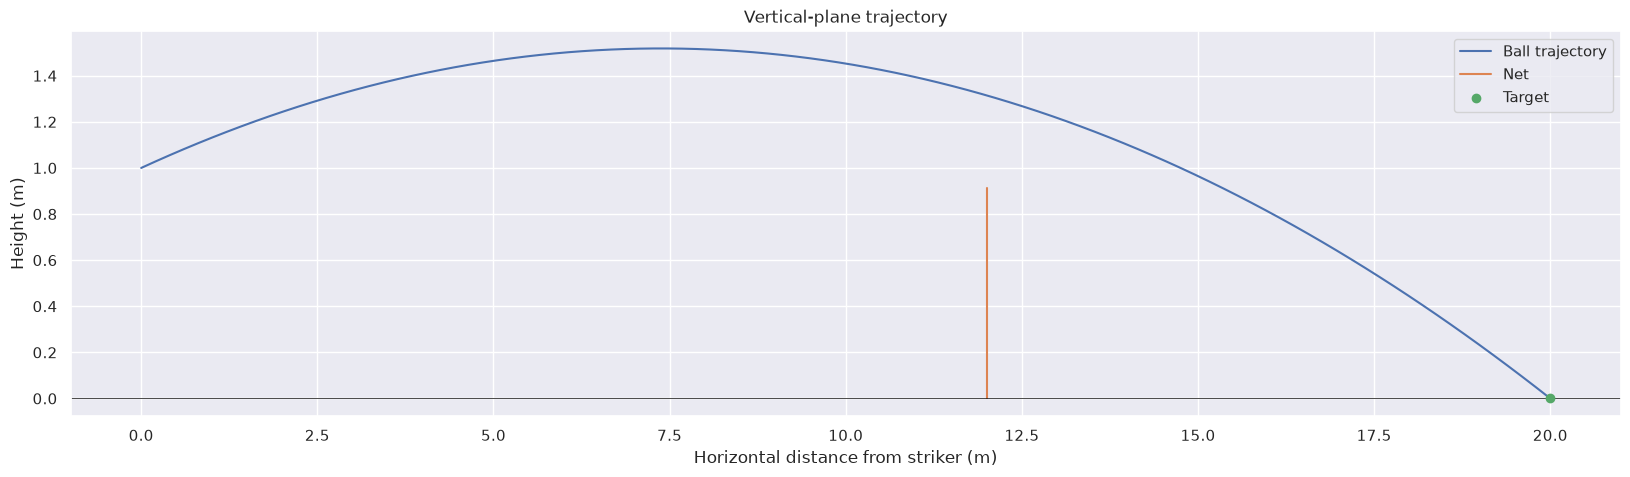

In [14]:
# Draw the arc, marking the net and the landing point.
utils.plot_trajectory(
    v0_fig1[0],
    theta_fig1[0],
    h0_fig1,
    d_net_fig1,
    racket_params.TENNIS.court.net_height_center_m,
    d_target[0],
)
# Outcome: a single arc clearing the net near its peak and landing at x=20 m.

# Part 3: Feasible Launch Set

## Cell 3.1: `FeasibleLaunches`: the mental model

- Holds every `(theta, v0)` pair, out of a caller-supplied angle grid, that
  clears the net, lands at the target, and stays within
  `sport.max_ball_speed_mps`

In [27]:
hintros.print_obj_info(racket_trajectory.FeasibleLaunches)

**FeasibleLaunches**

https://github.com/gpsaggese/gpsaggese.github.io/blob/UmdTask590_Implement_solution_for_optimal_strategy_for_racket_sports_1/research/Optimal_strategy_for_racket_sports/racket_trajectory.py#L27


## Cell 3.2: `get_feasible_launches()`: sweep a grid of launch angles

In [28]:
hintros.print_obj_info(racket_trajectory.get_feasible_launches)

- `get_feasible_launches(striker_xy: Tuple[float, float], target_xy: Tuple[float, float], h0: float, sport: research.Optimal_strategy_for_racket_sports.racket_params.SportParams, *, theta_grid_rad: numpy.ndarray) -> research.Optimal_strategy_for_racket_sports.racket_trajectory.FeasibleLaunches`  
  Feasible launch angles/speeds landing at `target_xy` from `striker_xy`.

https://github.com/gpsaggese/gpsaggese.github.io/blob/UmdTask590_Implement_solution_for_optimal_strategy_for_racket_sports_1/research/Optimal_strategy_for_racket_sports/racket_trajectory.py#L166


In [29]:
# Sweep 1-44 deg for a rally shot from the baseline to just past the net.
striker_xy = (0.0, -11.0)
target_xy = (0.0, 5.0)
h0 = 1.0
theta_grid_rad = np.radians(np.arange(1.0, 45.0, 1.0))
launches = racket_trajectory.get_feasible_launches(
    striker_xy,
    target_xy,
    h0,
    racket_params.TENNIS,
    theta_grid_rad=theta_grid_rad,
)
launches_df = pd.DataFrame(
    {
        "theta_deg": np.degrees(launches.theta_rad),
        "v0_mps": launches.v0_mps,
        "flight_time_s": launches.flight_time_s,
        "net_clearance_m": launches.net_clearance_m,
    }
)
print("num_feasible:", len(launches_df))
display(launches_df.head())
# Outcome: 38 of the 44 angles in the grid survive; only the flattest
# angles (1-6 deg) are dropped for not clearing the net, since 16 m is
# well within tennis's max ball speed even for the steepest angles tried.

num_feasible: 38


,theta_deg,v0_mps,flight_time_s,net_clearance_m
0,7.0,20.735245,0.777428,0.035416
1,8.0,19.853406,0.813827,0.096453
2,9.0,19.084334,0.848835,0.157790
3,10.0,18.407141,0.882637,0.219468
4,11.0,17.806047,0.915389,0.281526


## Cell 3.3: The `max_ball_speed_mps` constraint

- A sport (or player) with a very low max ball speed should have no
  feasible launches at all for a target this far away

In [30]:
# Build a custom SportParams with a tiny max_ball_speed_mps.
tiny_speed_sport = racket_params.SportParams(
    name="Tiny", court=racket_params.TENNIS.court, max_ball_speed_mps=0.5
)
tiny_launches = racket_trajectory.get_feasible_launches(
    striker_xy,
    target_xy,
    h0,
    tiny_speed_sport,
    theta_grid_rad=theta_grid_rad,
)
print("num_feasible:", len(tiny_launches.theta_rad))
# Outcome: 0 feasible launches, since every angle needs far more than
# 0.5 m/s to cover the 16 m from striker to target.

num_feasible: 0


# Part 4: Shot Error and Landing Simulation

## Cell 4.1: `ShotErrorModel` and `sample_shot_errors()`

- `ShotErrorModel` holds 3 standard deviations (angle, speed fraction,
  lateral azimuth); `sample_shot_errors()` draws `n_samples` of each

In [31]:
hintros.print_obj_info(racket_params.ShotErrorModel)

**ShotErrorModel**

https://github.com/gpsaggese/gpsaggese.github.io/blob/UmdTask590_Implement_solution_for_optimal_strategy_for_racket_sports_1/research/Optimal_strategy_for_racket_sports/racket_params.py#L138


In [32]:
hintros.print_obj_info(racket_trajectory.sample_shot_errors)

- `sample_shot_errors(error: research.Optimal_strategy_for_racket_sports.racket_params.ShotErrorModel, n_samples: int, rng: numpy.random._generator.Generator) -> research.Optimal_strategy_for_racket_sports.racket_trajectory.ShotErrors`  
  Draw `n_samples` shot execution errors from `error`.

https://github.com/gpsaggese/gpsaggese.github.io/blob/UmdTask590_Implement_solution_for_optimal_strategy_for_racket_sports_1/research/Optimal_strategy_for_racket_sports/racket_trajectory.py#L230


In [33]:
# Draw 5 error samples from the illustrative DEFAULT_ERROR model.
rng = np.random.default_rng(42)
errors = racket_trajectory.sample_shot_errors(
    racket_params.DEFAULT_ERROR, 5, rng
)
print("d_theta_rad:", errors.d_theta_rad)
print("d_v_frac:", errors.d_v_frac)
print("phi_rad:", errors.phi_rad)
# Outcome: 3 arrays of 5 small, zero-centered draws, one per error source.

d_theta_rad: [ 0.00797747 -0.02722672  0.01964677  0.02462393 -0.05107798]
d_v_frac: [-0.06510898  0.00639202 -0.01581213 -0.00084006 -0.0426522 ]
phi_rad: [0.02302259 0.02036255 0.00172868 0.02951111 0.01223937]


In [34]:
# Same seed drawn twice gives identical samples (common random numbers).
errors_again = racket_trajectory.sample_shot_errors(
    racket_params.DEFAULT_ERROR, 5, np.random.default_rng(42)
)
print(
    "same draws:",
    np.array_equal(errors.d_theta_rad, errors_again.d_theta_rad),
)
# Outcome: True, since `rng` is passed in rather than seeded globally inside
# the function.

same draws: True


## Cell 4.2: `Landings` and `simulate_landings()`

- Perturbs every launch in a `FeasibleLaunches` by every sample in a
  `ShotErrors`, producing an `(L, K)` grid of landing points

In [35]:
hintros.print_obj_info(racket_trajectory.Landings)

**Landings**

https://github.com/gpsaggese/gpsaggese.github.io/blob/UmdTask590_Implement_solution_for_optimal_strategy_for_racket_sports_1/research/Optimal_strategy_for_racket_sports/racket_trajectory.py#L67


In [36]:
hintros.print_obj_info(racket_trajectory.simulate_landings)

- `simulate_landings(striker_xy: Tuple[float, float], target_xy: Tuple[float, float], h0: float, sport: research.Optimal_strategy_for_racket_sports.racket_params.SportParams, launches: research.Optimal_strategy_for_racket_sports.racket_trajectory.FeasibleLaunches, errors: research.Optimal_strategy_for_racket_sports.racket_trajectory.ShotErrors) -> research.Optimal_strategy_for_racket_sports.racket_trajectory.Landings`  
  Simulate landing points for every (launch, error sample) pair.

https://github.com/gpsaggese/gpsaggese.github.io/blob/UmdTask590_Implement_solution_for_optimal_strategy_for_racket_sports_1/research/Optimal_strategy_for_racket_sports/racket_trajectory.py#L258


In [37]:
# Sanity check: zero-valued errors should land exactly on the nominal target.
zero_errors = racket_trajectory.ShotErrors(
    d_theta_rad=np.zeros(1), d_v_frac=np.zeros(1), phi_rad=np.zeros(1)
)
zero_landings = racket_trajectory.simulate_landings(
    striker_xy, target_xy, h0, racket_params.TENNIS, launches, zero_errors
)
print("x_m.shape:", zero_landings.x_m.shape)
print("all land at target_xy:", np.allclose(zero_landings.y_m, target_xy[1]))
# Outcome: shape (num_feasible, 1), and every launch lands exactly at
# target_xy=(0.0, 5.0), since there is no error to perturb the aim.

x_m.shape: (38, 1)
all land at target_xy: True


## Cell 4.3: Visualize landing dispersion

- Same launches, but now perturbed by 200 samples of the illustrative
  `DEFAULT_ERROR` model

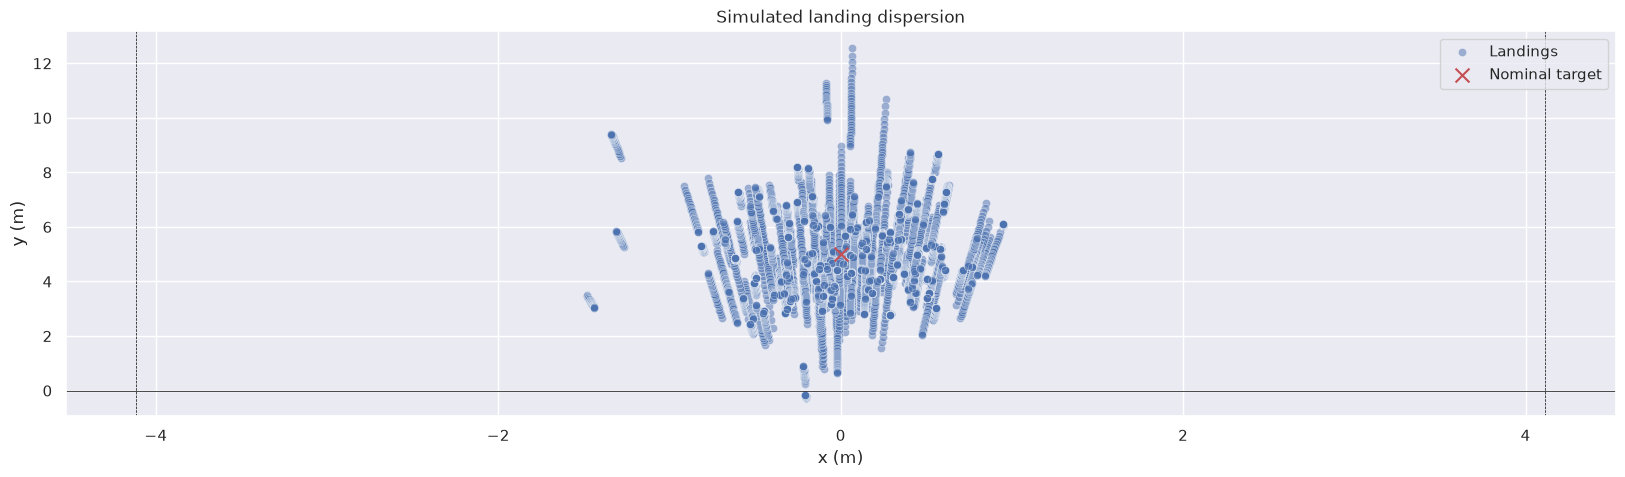

In [38]:
# Simulate landings under realistic (illustrative) shot execution noise.
noisy_errors = racket_trajectory.sample_shot_errors(
    racket_params.DEFAULT_ERROR, 200, np.random.default_rng(0)
)
noisy_landings = racket_trajectory.simulate_landings(
    striker_xy, target_xy, h0, racket_params.TENNIS, launches, noisy_errors
)
utils.plot_landing_scatter(
    noisy_landings.x_m, noisy_landings.y_m, target_xy, racket_params.TENNIS.court
)
# Outcome: a cloud of landing points centered on the target, spread by the
# error model's angle, speed, and azimuth noise.

**Interactive exploration**
- What happens to the spread of the cloud if `sigma_phi_rad` is doubled
  via `dataclasses.replace(racket_params.DEFAULT_ERROR, ...)`?
- What return type does `simulate_landings()` give for `clears_net`? Try
  `noisy_landings.clears_net.dtype`

## Summary: The Mental Model

- `racket_params.py` supplies the static facts (court geometry, sport
  speed limits, illustrative player/error defaults); `racket_trajectory.py`
  never hardcodes a number, it always reads them from a `SportParams`
- A shot is fully described by `(theta, v0)`; `get_height_at()` and
  `get_flight_time()` are the two closed-form building blocks every other
  function composes
- `get_feasible_launches()` turns a 1D angle sweep into the set of shots
  that are physically possible for one target, `simulate_landings()` then
  fans each of those shots out by sampled execution error into a `(L, K)`
  grid of real landing points